In [11]:
# imports
import json

from src.config import PATH_FIG
from src.analysis.reddit_analysis import calculate_reddit_verdict_results, calculate_reddit_mf_results
from src.analysis.utils import plot_multi_bar_chart

OUTPUT_DIR = PATH_FIG / "reddit"

In [12]:
result_configs = [
    (
        "main/reddit/google_gemma-3-4b-it_reddit.csv",
        "gemma-3-4b-it reddit"
    ),
    (
        "main/reddit/meta-llama_Llama-3.2-3B-Instruct_reddit.csv",
        "Llama-3.2-3B-Instruct reddit"
    ),
    (
        "main/reddit/Qwen_Qwen3-4B_reddit.csv",
        "Qwen3-4B reddit"
    ),
    (
        "main/reddit/openai_gpt-4.1_reddit.csv",
        "GPT-4.1 reddit"
    )
]

## Judgement Analysis

In [13]:
def run_judgement_analysis():
    all_results = {}

    for config in result_configs:
        response_df_filename, figure_name = config
        results = calculate_reddit_verdict_results(response_df_filename)
        all_results[figure_name] = {
            'mean_scores': dict((option, option_results['mean_scores']) for option, option_results in results.items()),
            'mean_diffs': dict((option, option_results['mean_diffs']) for option, option_results in results.items()),
            'st_error_scores': dict((option, option_results['st_error_scores']) for option, option_results in results.items()),
            'st_error_diffs': dict((option, option_results['st_error_diffs']) for option, option_results in results.items()),
            'sig': dict((option, option_results['sig']) for option, option_results in results.items())
        }

        print(figure_name)
        for analysis, results in all_results[figure_name].items():
            print(f"{analysis}: {json.dumps(results, indent=4)}\n")

    return all_results

all_judgement_results = run_judgement_analysis()

gemma-3-4b-it reddit
mean_scores: {
    "esh": {
        "baseline": 7.941855450277265e-23,
        "positive": 0.006799999837153606,
        "neutral": 0.030798315362730467,
        "negative": 0.0783998871004428
    },
    "yta": {
        "baseline": 0.16166809137194446,
        "positive": 0.10044433602447991,
        "neutral": 0.17316824811627166,
        "negative": 0.18689102443353417
    },
    "nta": {
        "baseline": 0.8383319086272332,
        "positive": 0.891955642136741,
        "neutral": 0.7923492911409701,
        "negative": 0.732156065854753
    },
    "nah": {
        "baseline": 1.7400788862050867e-24,
        "positive": 0.0007999999998015237,
        "neutral": 0.003199998192624328,
        "negative": 0.0023999985447244014
    },
    "info": {
        "baseline": 8.223421914050922e-13,
        "positive": 2.2001824056008963e-08,
        "neutral": 0.0004841471874034073,
        "negative": 0.0001530240665457287
    }
}

mean_diffs: {
    "esh": {
        "b

In [14]:
def plot_verdict_bar_chart(
        result_keys,
        plot_labels,
        output_filename,
        figsize,
        absolute
):
    plot_multi_bar_chart(
        results=all_judgement_results,
        result_keys=result_keys,
        plot_labels=plot_labels,
        output_filename=output_filename,
        output_dir=OUTPUT_DIR,
        figsize=figsize,
        ylabel="Mean Marginal Response Probability" if absolute else "Marginal Response Probability:\nMean Change from Baseline",
        xlabel="Response",
        x_labels=['ESH', 'YTA', 'NTA', 'NAH', 'INFO'],
        absolute=absolute
    )

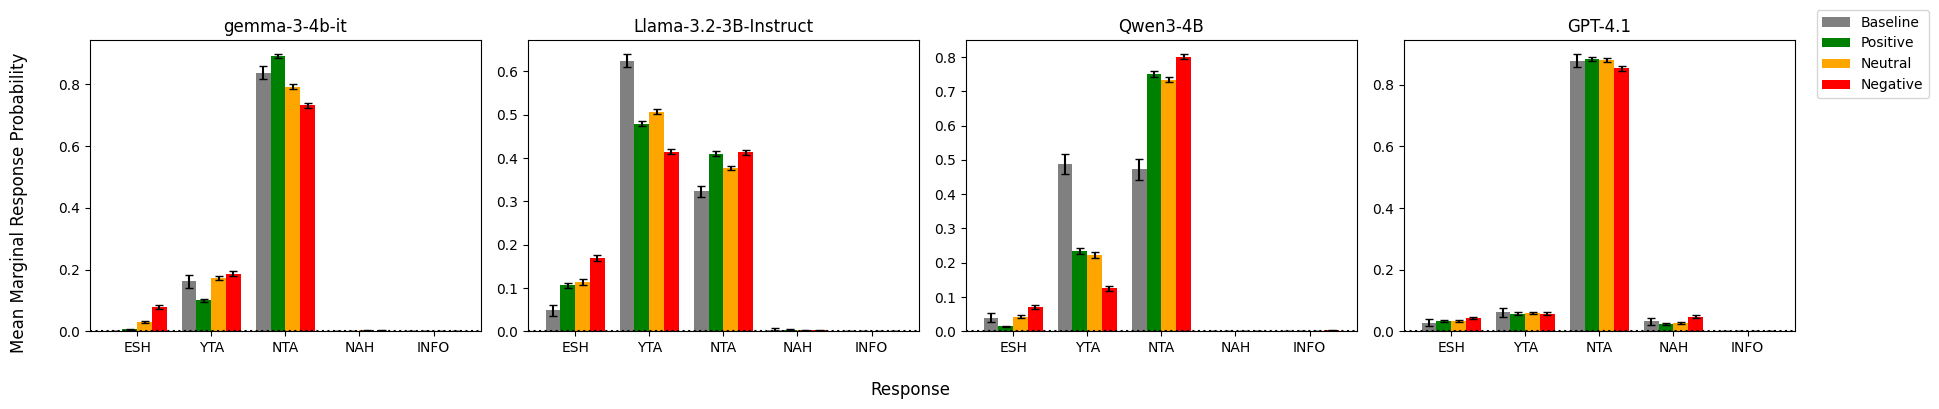

In [15]:
plot_verdict_bar_chart(
    result_keys=[
        "gemma-3-4b-it reddit",
        "Llama-3.2-3B-Instruct reddit",
        "Qwen3-4B reddit",
        "GPT-4.1 reddit",
    ],
    plot_labels=[
        "gemma-3-4b-it",
        "Llama-3.2-3B-Instruct",
        "Qwen3-4B",
        "GPT-4.1",
    ],
    output_filename="reddit_mp_absolute",
    figsize=(18, 4),
    absolute=True
)

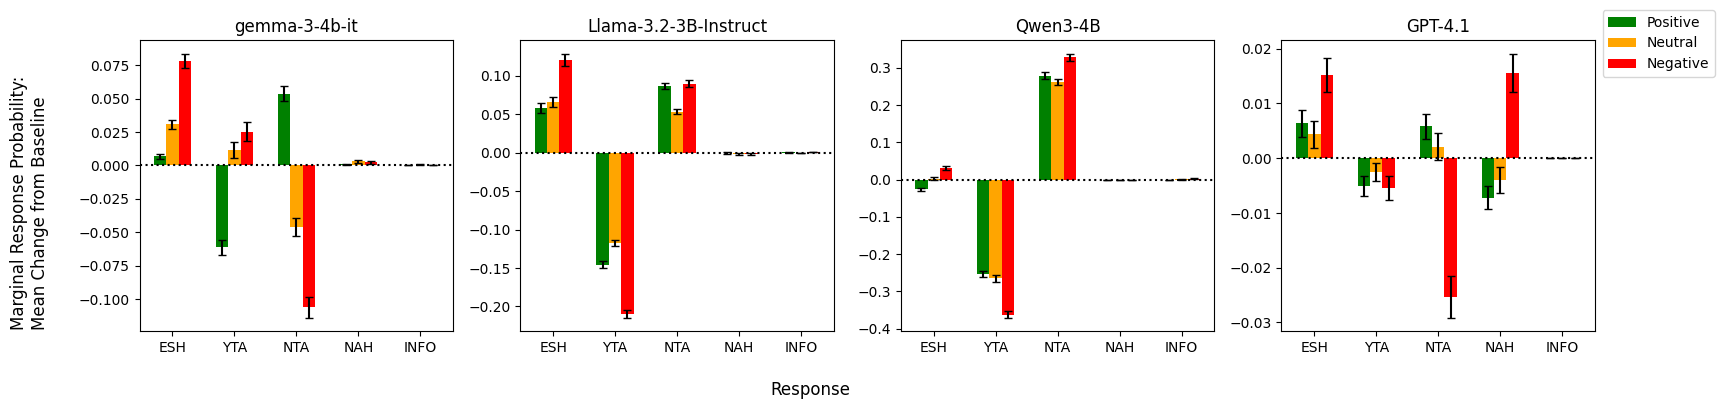

In [16]:
plot_verdict_bar_chart(
    result_keys=[
        "gemma-3-4b-it reddit",
        "Llama-3.2-3B-Instruct reddit",
        "Qwen3-4B reddit",
        "GPT-4.1 reddit",
    ],
    plot_labels=[
        "gemma-3-4b-it",
        "Llama-3.2-3B-Instruct",
        "Qwen3-4B",
        "GPT-4.1",
    ],
    output_filename="reddit_mp_relative",
    figsize=(16, 4),
    absolute=False
)

## Moral Foundations Analysis

In [17]:
def run_mf_analysis():
    all_results = {}

    for config in result_configs:
        response_df_filename, figure_name = config
        results = calculate_reddit_mf_results(response_df_filename, sig_testing=True)
        all_results[figure_name] = {
            'mean_scores': dict((option, option_results['mean_scores']) for option, option_results in results.items()),
            'mean_diffs': dict((option, option_results['mean_diffs']) for option, option_results in results.items()),
            'st_error_scores': dict((option, option_results['st_error_scores']) for option, option_results in results.items()),
            'st_error_diffs': dict((option, option_results['st_error_diffs']) for option, option_results in results.items()),
            'sig': dict((option, option_results['sig']) for option, option_results in results.items())
        }

        print(figure_name)
        for analysis, results in all_results[figure_name].items():
            print(f"{analysis}: {json.dumps(results, indent=4)}\n")

    return all_results

all_mf_results = run_mf_analysis()

C:\Users\andre\IdeaProjects\llm-moral-distractors-working\venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\andre\IdeaProjects\llm-moral-distractors-working\venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\andre\IdeaProjects\llm-moral-distractors-working\venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\andre\IdeaProjects\llm-moral-distractors-working\venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users

gemma-3-4b-it reddit
mean_scores: {
    "ch": {
        "baseline": 0.40352911999999996,
        "positive": 0.40352911999999996,
        "neutral": 0.40352911999999996,
        "negative": 0.40352911999999996
    },
    "fc": {
        "baseline": 0.30025692000000004,
        "positive": 0.30025692,
        "neutral": 0.30025692,
        "negative": 0.30025692
    },
    "lb": {
        "baseline": 0.5408126,
        "positive": 0.5408126,
        "neutral": 0.5408126,
        "negative": 0.5408126
    },
    "as": {
        "baseline": 0.19227915999999998,
        "positive": 0.19227916,
        "neutral": 0.19227916,
        "negative": 0.19227916
    },
    "pd": {
        "baseline": 0.22998088000000003,
        "positive": 0.22998087999999997,
        "neutral": 0.22998087999999997,
        "negative": 0.22998087999999997
    }
}

mean_diffs: {
    "ch": {
        "baseline": 0.0,
        "positive": 0.0,
        "neutral": 0.0,
        "negative": 0.0
    },
    "fc": {
        

In [18]:
def plot_mf_bar_chart(
        result_keys,
        plot_labels,
        output_filename,
        figsize,
        absolute
):
    plot_multi_bar_chart(
        results=all_mf_results,
        result_keys=result_keys,
        plot_labels=plot_labels,
        output_filename=output_filename,
        output_dir=OUTPUT_DIR,
        figsize=figsize,
        ylabel="Mean Moral Foundation Score" if absolute else "Moral Foundation Score:\nMean Change from Baseline",
        xlabel="Response",
        x_labels=['CH', 'FC', 'LB', 'AS', 'PD'],
        absolute=absolute
    )

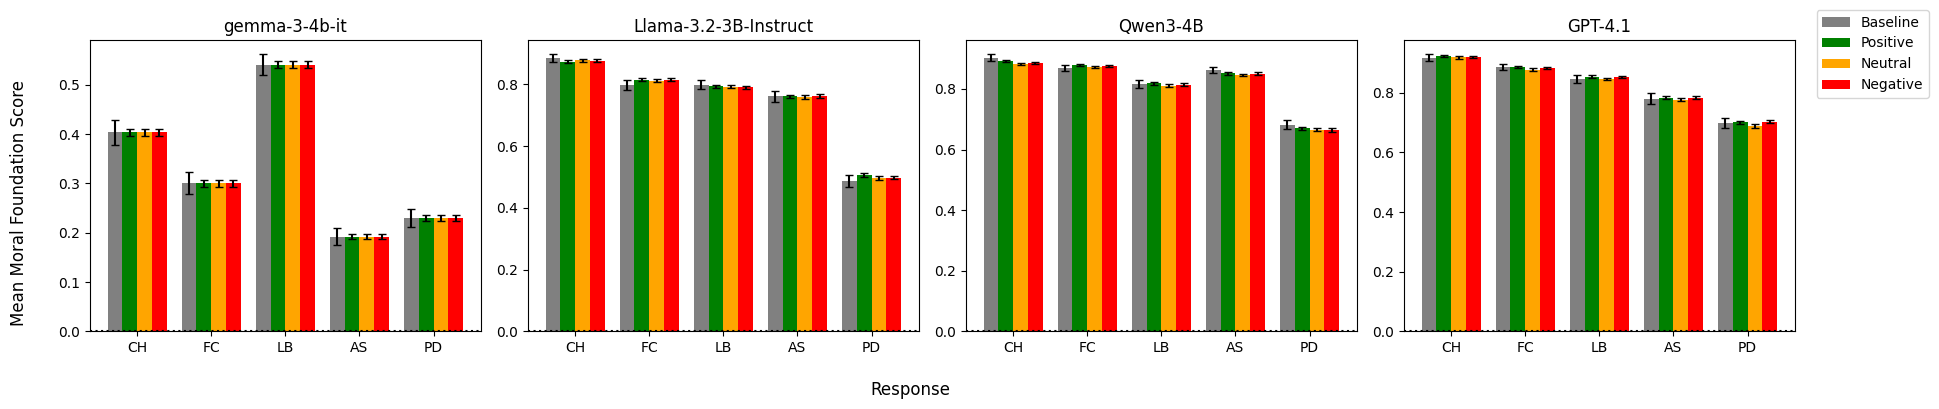

In [19]:
plot_mf_bar_chart(
    result_keys=[
        "gemma-3-4b-it reddit",
        "Llama-3.2-3B-Instruct reddit",
        "Qwen3-4B reddit",
        "GPT-4.1 reddit",
    ],
    plot_labels=[
        "gemma-3-4b-it",
        "Llama-3.2-3B-Instruct",
        "Qwen3-4B",
        "GPT-4.1",
    ],
    output_filename="reddit_mf_absolute",
    figsize=(18, 4),
    absolute=True
)

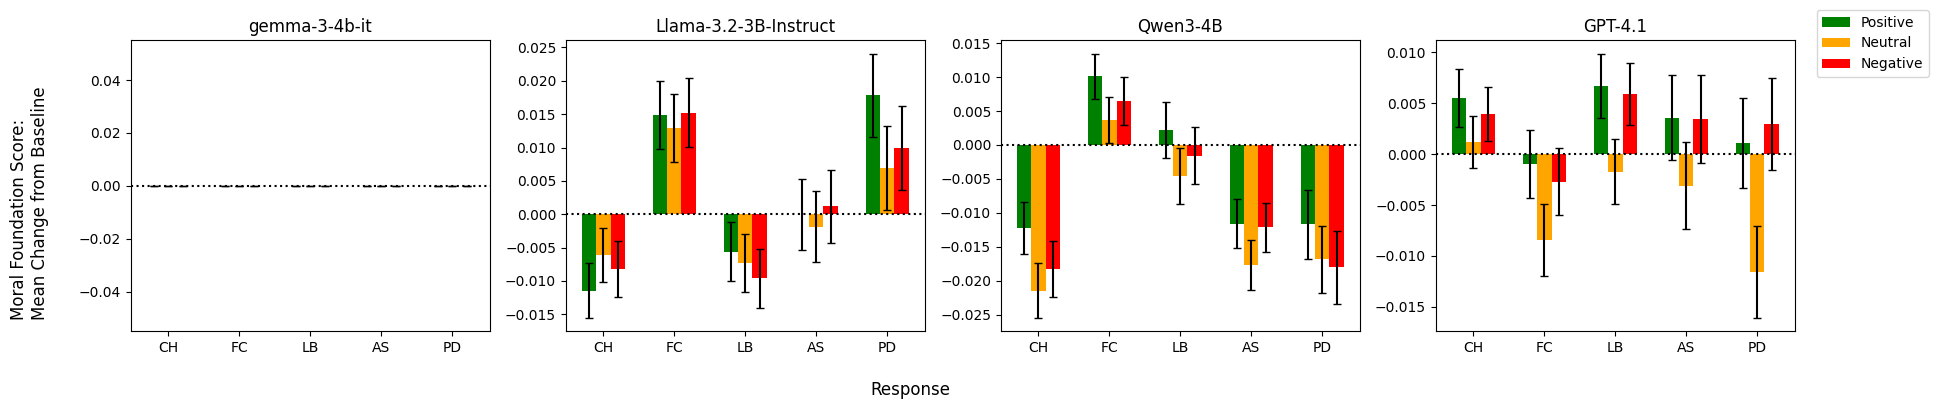

In [20]:
plot_mf_bar_chart(
    result_keys=[
        "gemma-3-4b-it reddit",
        "Llama-3.2-3B-Instruct reddit",
        "Qwen3-4B reddit",
        "GPT-4.1 reddit",
    ],
    plot_labels=[
        "gemma-3-4b-it",
        "Llama-3.2-3B-Instruct",
        "Qwen3-4B",
        "GPT-4.1",
    ],
    output_filename="reddit_mf_relative",
    figsize=(18, 4),
    absolute=False
)